Title: Mean_and_anomaly_calculatiMean_and_anomaly_calculations_VRES_variabilityons_VRES.ipynb

Purpose: Calculate a model mean and the wind anomaly data

Author: Onno Nennecke on 02.06.2025 Modified: 15.06.2026

Input data: 

- Wind Data from ERA5 and CMIP
    - These files lie here: /climca/people/onennecke/not_debiased_data/
- Used Runs File: CMIP6_runs.csv
    - These files lie here: /home/onennecke/CMIP_models/

Output data:

- Wind winter means Data: wind_mean_combined.nc
    - This file lies here: /climca/people/onennecke/model_output/var_means/Wind_not_bc/
- Wind Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/wind_anomaly/not_bc/
- Wind composite data
    - This file lies here: //climca/people/onennecke/model_output/composites

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime

### Load VRES Dates

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
ts_datasets = xr.open_dataset(path)
ts_datasets.load()

ts_datasets_week = ts_datasets.sel(ESM_run=ts_datasets.ESM_run[ts_datasets.period == 'week'])
RL_week = ts_datasets_week['Residual_load']
thresh_perc = 0.95
threshold_week = np.quantile(RL_week.values.flatten(), thresh_perc)
threshold_week

# Create a boolean mask for values above the threshold
mask_week = RL_week > threshold_week
mask_week

<xarray.DataArray 'Residual_load' (ESM_run: 193, time: 3650)> Size: 704kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False,  True],
       [False, False, False, ..., False,  True,  True]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'week'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

## Choose variable

In [3]:
# 
# ['sfcWind', 'tas', 'rsds', 'tasmax']
var = 'rsds'

### Read data

In [4]:
# Read the dataframe from the csv file
used_runs_CMIP = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs_future.csv')

used_runs_CESM = pd.read_csv('/home/onennecke/CMIP_models/CESM2_LE_runs.csv')

used_runs = pd.concat([used_runs_CMIP, used_runs_CESM], ignore_index=True)

# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)


# Change the ref column to 1 for the first instance of each model
used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

used_runs['names'] = used_runs['ESM'] + '_' + used_runs['run']

ESMs = used_runs['ESM'].unique()

used_runs

,ESM,Institution,run,Ref,names
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1,1,ACCESS-CM2_r4i1p1f1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1,0,ACCESS-CM2_r5i1p1f1
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1,0,ACCESS-CM2_r1i1p1f1
3,BCC-CSM2-MR,BCC,r1i1p1f1,1,BCC-CSM2-MR_r1i1p1f1
4,CESM2,NCAR,r4i1p1f1,1,CESM2_r4i1p1f1
...,...,...,...,...,...
188,CESM2,NCAR,LE2-1301_017,0,CESM2_LE2-1301_017
189,CESM2,NCAR,LE2-1301_018,0,CESM2_LE2-1301_018
190,CESM2,NCAR,LE2-1301_019,0,CESM2_LE2-1301_019
191,CESM2,NCAR,LE2-1301_020,0,CESM2_LE2-1301_020


In [5]:
base_path = '/climca/people/onennecke/not_debiased_data/'

# Show all files in the base path
files = os.listdir(base_path)
Var_files = [fn for fn in files if f'_{var}.' in os.path.basename(fn)]
print(len(Var_files))

# Filter Var_files to only include those that are in the used_runs dataframe
Var_files = [fn for fn in Var_files if any(name in fn for name in used_runs['names'])] 
print(len(Var_files))

# Combine the base path with the file names
Var_files = [os.path.join(base_path, fn) for fn in Var_files]

Var_ds = xr.open_dataset(Var_files[0])  # Open the first file to check the structure
Var_ds.load()

# Open the files using xarray
# Var_ds = xr.open_mfdataset(Var_files, combine='by_coords')

201
193


<xarray.Dataset> Size: 1MB
Dimensions:   (time: 3650, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U8 32B 'CESM2_LE'
    run       <U12 48B 'LE2-1281_010'
    ESM_run   <U21 84B 'CESM2_LE_LE2-1281_010'
Data variables:
    rsds      (time, lat, lon) float32 1MB 0.0 0.0 0.0 0.0 ... 28.57 23.48 16.11
Attributes:
    regrid_method:  bilinear

---

In [6]:
path = f'/climca/people/onennecke/model_output/var_anomalies_VRES/'
# path = f'/climca/people/onennecke/model_output/var_anomalies_VRES_against_VRES/'

files = sorted(glob.glob(os.path.join(path, f'*{var}*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 127MB
Dimensions:   (ESM_run: 193, time: 1820, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    <U4 16B 'week'
Data variables:
    rsds      (ESM_run, time, lat, lon) float32 126MB dask.array<chunksize=(1, 1820, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### Load cluster data

In [7]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

In [8]:
path = f'/climca/people/onennecke/model_output/var_anomalies/'

files = sorted(glob.glob(os.path.join(path, f'*{var}*.nc')))
ts_datasets_filler = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

# ts_datasets_filler

In [9]:
# Read this cluster_da.to_netcdf('/home/onennecke/psl_clustering/cluster_assignments_all_days.nc')
cluster_da = xr.open_dataarray('/home/onennecke/psl_clustering/cluster_assignments_all_days.nc')
cluster_da = cluster_da.assign_coords(time=ts_datasets_filler.time)
cluster_da


<xarray.DataArray (ESM_run: 193, time: 1820)> Size: 3MB
[351260 values with dtype=int64]
Coordinates:
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31

In [10]:
cluster_aligned = cluster_da.sel(time=ts_datasets.time)
cluster_aligned
ts_datasets = ts_datasets.assign_coords(cluster=cluster_aligned)
ts_datasets

<xarray.Dataset> Size: 129MB
Dimensions:   (ESM_run: 193, time: 1820, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    <U4 16B 'week'
    cluster   (ESM_run, time) int64 3MB ...
Data variables:
    rsds      (ESM_run, time, lat, lon) float32 126MB dask.array<chunksize=(1, 1820, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [11]:
spatial_mean = ts_datasets.mean(dim=['lat', 'lon'], skipna=True)
spatial_mean.compute()

<xarray.Dataset> Size: 4MB
Dimensions:   (ESM_run: 193, time: 1820)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    <U4 16B 'week'
    cluster   (ESM_run, time) int64 3MB 3 2 3 1 1 2 2 3 3 ... 0 3 3 3 3 3 2 2 3
Data variables:
    rsds      (ESM_run, time) float32 1MB -26.94 -16.44 -3.67 ... -7.403 4.066

In [12]:
stacked = spatial_mean.stack(sample=("ESM_run", "time"))

# Filter stacked to not include NaN values in the var column
stacked_filtered = stacked.dropna(dim='sample', subset=[var])
stacked_filtered

<xarray.Dataset> Size: 77MB
Dimensions:   (sample: 351260)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (sample) <U13 18MB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (sample) <U12 17MB 'r1i1p1f1' 'r1i1p1f1' ... 'r8i1p1f2' 'r8i1p1f2'
    country   float64 8B 9.0
    period    <U4 16B 'week'
    cluster   (sample) int64 3MB 3 2 3 1 1 2 2 3 3 1 1 ... 0 0 0 3 3 3 3 3 2 2 3
  * sample    (sample) object 3MB MultiIndex
  * ESM_run   (sample) <U23 32MB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1p...
  * time      (sample) datetime64[ns] 3MB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    rsds      (sample) float32 1MB dask.array<chunksize=(1820,), meta=np.ndarray>

In [17]:
# Count non nan values in ts_datasets[var]
non_nan_count = np.sum(~np.isnan(stacked[var].values))
print(f"Number of non-NaN values in {var}: {non_nan_count}")

Number of non-NaN values in rsds: 351260


In [13]:
grouped = stacked_filtered[var].groupby("cluster")

data = [group.values for _, group in grouped]
labels = list(grouped.groups.keys())

/tmp/ipykernel_383240/3119950779.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


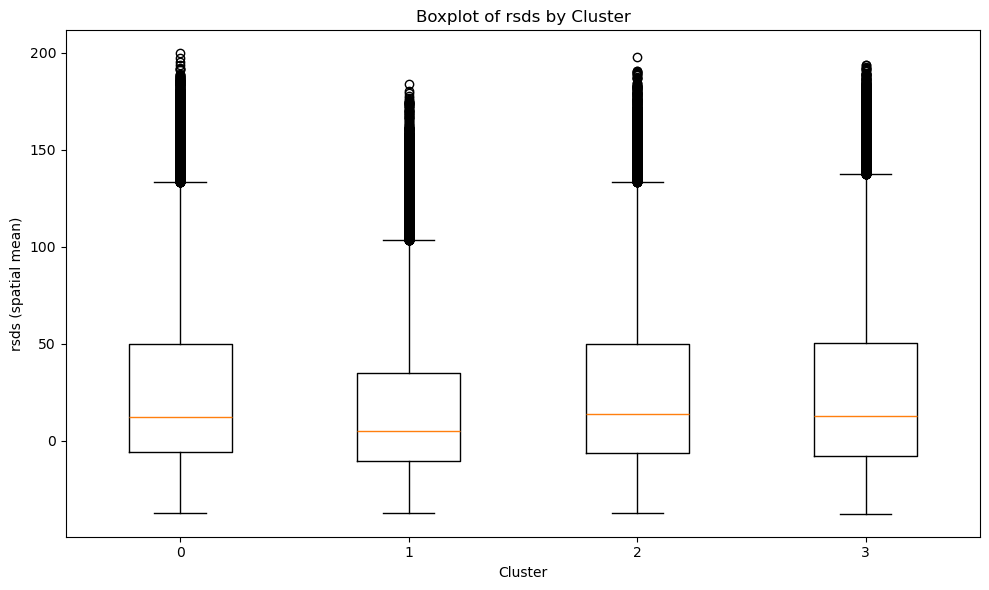

In [14]:
plt.figure(figsize=(10,6))
plt.boxplot(data, labels=labels)
plt.xlabel("Cluster")
plt.ylabel(f"{var} (spatial mean)")
plt.title(f"Boxplot of {var} by Cluster")
plt.tight_layout()
plt.show()

/tmp/ipykernel_336325/3119950779.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


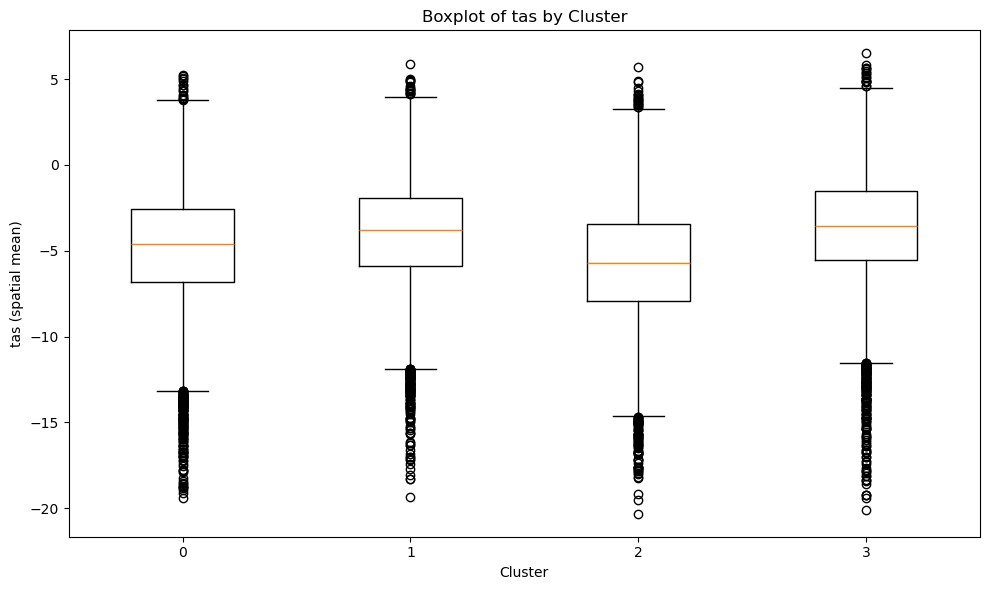

In [15]:
plt.figure(figsize=(10,6))
plt.boxplot(data, labels=labels)
plt.xlabel("Cluster")
plt.ylabel(f"{var} (spatial mean)")
plt.title(f"Boxplot of {var} by Cluster")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2834436/3119950779.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


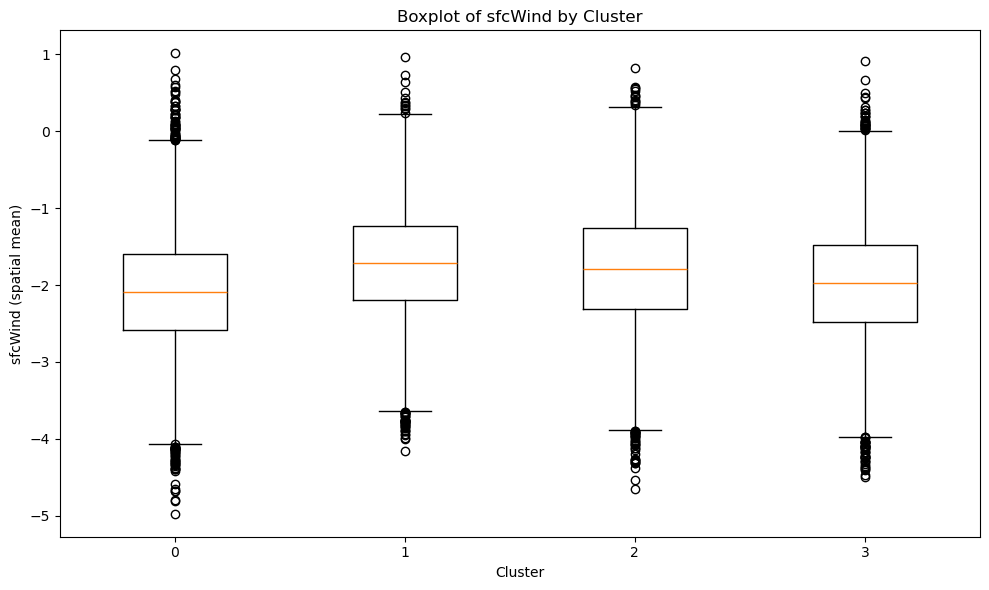

In [126]:
plt.figure(figsize=(10,6))
plt.boxplot(data, labels=labels)
plt.xlabel("Cluster")
plt.ylabel(f"{var} (spatial mean)")
plt.title(f"Boxplot of {var} by Cluster")
plt.tight_layout()
plt.show()

In [15]:
variability = stacked_filtered.groupby(stacked_filtered.cluster).var(dim="sample", skipna=True)
variability.load()

<xarray.Dataset> Size: 104B
Dimensions:   (cluster: 4)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'
  * cluster   (cluster) int64 32B 0 1 2 3
Data variables:
    rsds      (cluster) float32 16B 1.953e+03 1.171e+03 1.66e+03 1.713e+03

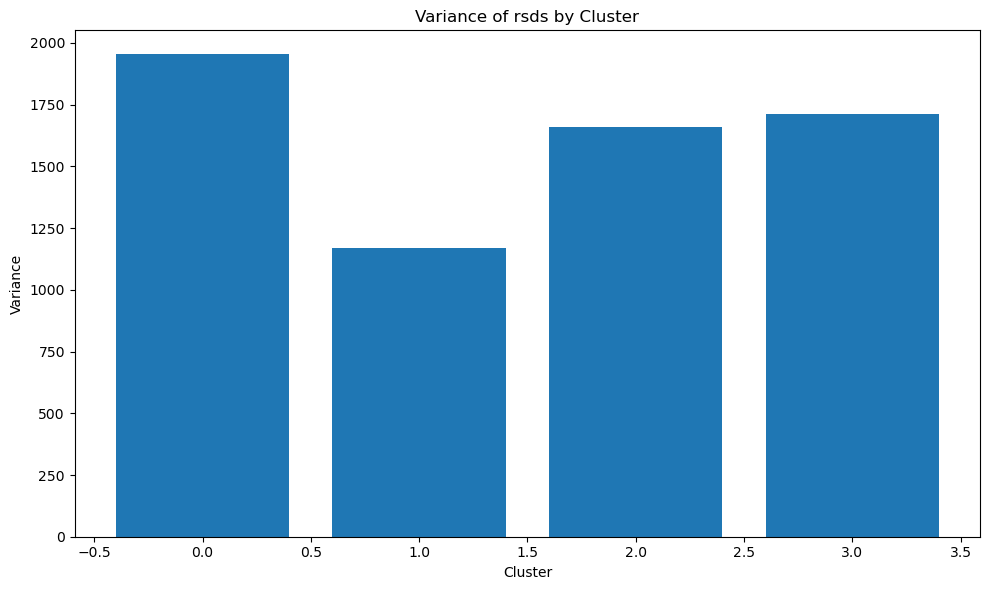

In [16]:
# Plot variability as a bar plot

plt.figure(figsize=(10, 6))
plt.bar(variability.cluster, variability[var].values)
plt.xlabel('Cluster')
plt.ylabel('Variance')
plt.title(f'Variance of {var} by Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

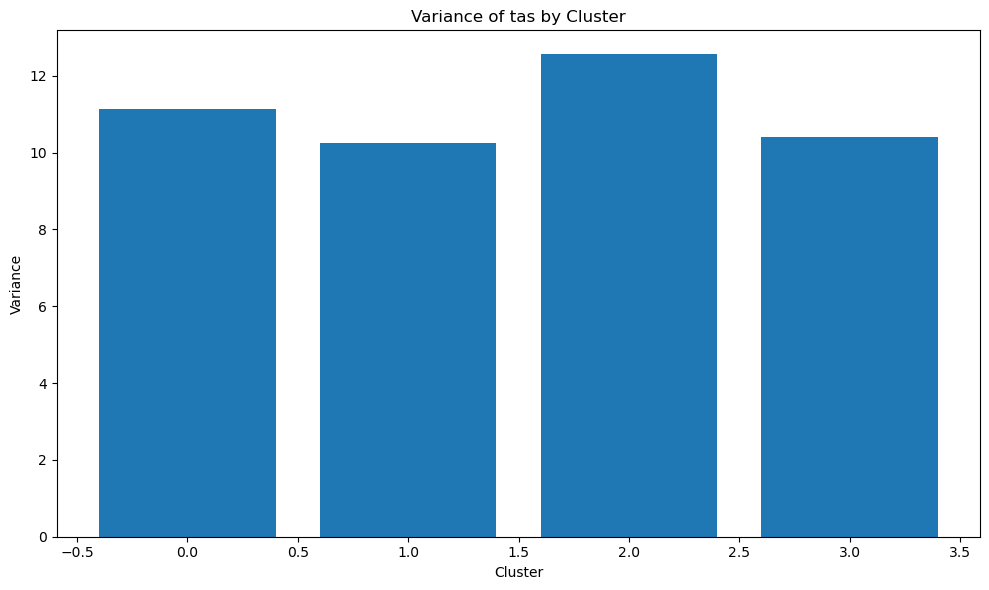

In [17]:
# Plot variability as a bar plot

plt.figure(figsize=(10, 6))
plt.bar(variability.cluster, variability[var].values)
plt.xlabel('Cluster')
plt.ylabel('Variance')
plt.title(f'Variance of {var} by Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

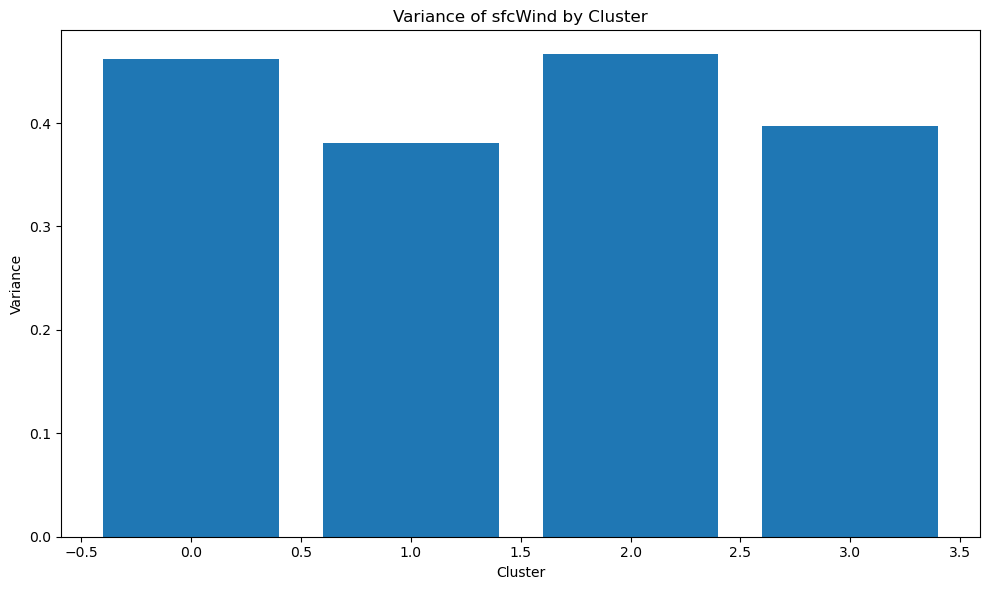

In [70]:
# Plot variability as a bar plot

plt.figure(figsize=(10, 6))
plt.bar(variability.cluster, variability[var].values)
plt.xlabel('Cluster')
plt.ylabel('Variance')
plt.title(f'Variance of {var} by Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()